# GeoQuant — Notebook de análisis comparativo PTQ vs QAT

Este notebook compara **PTQ** y **QAT** usando los bloques **A, B, C y D** y, además, explora **distribuciones, percentiles, outliers, análisis por clase y espectro singular** para ayudarte a interpretar qué te están diciendo las métricas.

La idea es que cada sección:
1. calcule la métrica principal,
2. compare **PTQ vs QAT**,
3. y luego mire algo **más allá del escalar** para entender el comportamiento del espacio de embeddings.

## Qué necesitas antes de correrlo

Ajusta en la siguiente celda:

- las rutas de los embeddings **baseline FP32**, **PTQ** y **QAT**;
- la ruta de `labels.pt` o el archivo donde tengas las etiquetas;
- la ruta base del proyecto para cargar los módulos `block_a.py`, `block_b.py`, `block_c.py` y `block_d.py` directamente desde archivo.

> Este notebook evita el problema de import circular cargando los módulos directamente desde sus archivos `.py`.

In [1]:
import math
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path(r"D:/GeoQuant-MobileNet")
EVAL_DIR = PROJECT_ROOT / "src" / "geoquant" / "evaluation"

# Cada archivo .pt es un dict {"embeddings": tensor (N, D), "labels": tensor (N,)}
EMB_FP32_PATH = PROJECT_ROOT / "outputs" / "embeddings" / "emb_fp32.pt"
EMB_PTQ_PATH  = PROJECT_ROOT / "outputs" / "embeddings" / "emb_ptq.pt"
EMB_QAT_PATH  = PROJECT_ROOT / "outputs" / "embeddings" / "emb_qat.pt"

# Configuración de análisis
K_VALUES = [1, 5, 10, 20]
TOP_OUTLIERS = 15
PAIRWISE_SAMPLE_SIZE = 2000   # para análisis globales costosos
CLASS_SAMPLE_LIMIT = None     # puedes poner, por ejemplo, 50 para acelerar análisis por clase
torch.set_printoptions(precision=6, sci_mode=False)

## Helpers generales

In [3]:
def load_module_from_file(module_name: str, file_path: Path):
    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

block_a = load_module_from_file("block_a", EVAL_DIR / "block_a.py")
block_b = load_module_from_file("block_b", EVAL_DIR / "block_b.py")
block_c = load_module_from_file("block_c", EVAL_DIR / "block_c.py")
block_d = load_module_from_file("block_d", EVAL_DIR / "block_d.py")

print("Módulos cargados correctamente.")

Módulos cargados correctamente.


In [4]:
from IPython.display import display

def summarize_array(x, name="metric"):
    x = np.asarray(x, dtype=np.float64)
    return pd.Series({
        "name": name,
        "count": x.size,
        "mean": x.mean(),
        "std": x.std(ddof=0),
        "min": x.min(),
        "p25": np.percentile(x, 25),
        "median": np.median(x),
        "p75": np.percentile(x, 75),
        "p90": np.percentile(x, 90),
        "p95": np.percentile(x, 95),
        "p99": np.percentile(x, 99),
        "max": x.max(),
    })

def ecdf_values(x):
    x = np.sort(np.asarray(x, dtype=np.float64))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

def to_numpy(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)

def print_heading(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

def load_emb_and_labels(path: Path):
    """
    Carga un archivo .pt producido por geoquant.evaluation.embeddings.save_embeddings.
    Devuelve (embeddings, labels). Acepta también el formato legado de tensor plano.
    """
    obj = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(obj, dict) and "embeddings" in obj and "labels" in obj:
        return obj["embeddings"], obj["labels"]
    if isinstance(obj, torch.Tensor):
        return obj, None
    raise TypeError(f"{path} tiene un formato no soportado: {type(obj)}")

def maybe_subsample_rows(x: torch.Tensor, max_rows: int | None = None, seed: int = 42):
    if max_rows is None or x.shape[0] <= max_rows:
        return x
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(x.shape[0], generator=g)[:max_rows]
    return x[idx]

def normalized_embeddings(x: torch.Tensor) -> torch.Tensor:
    return torch.nn.functional.normalize(x.float(), dim=1)

def pairwise_cosine_sample(emb: torch.Tensor, max_rows: int = 2000, seed: int = 42):
    emb = maybe_subsample_rows(normalized_embeddings(emb), max_rows=max_rows, seed=seed)
    sim = emb @ emb.T
    mask = ~torch.eye(sim.shape[0], dtype=torch.bool)
    return sim[mask].cpu().numpy()

def singular_spectrum(emb: torch.Tensor):
    x = emb.float() - emb.float().mean(dim=0)
    _, s, _ = torch.linalg.svd(x, full_matrices=False)
    s = s.cpu().numpy()
    p = s / max(s.sum(), 1e-8)
    cum = np.cumsum(p)
    return s, p, cum

## Carga de embeddings y etiquetas

In [5]:
emb_fp32, labels_fp32 = load_emb_and_labels(EMB_FP32_PATH)
emb_ptq,  labels_ptq  = load_emb_and_labels(EMB_PTQ_PATH)
emb_qat,  labels_qat  = load_emb_and_labels(EMB_QAT_PATH)

# Las etiquetas vienen embebidas en cada archivo y deben coincidir entre las tres variantes.
for other_name, other in [("PTQ", labels_ptq), ("QAT", labels_qat)]:
    if other is not None and not torch.equal(labels_fp32, other):
        raise ValueError(f"Las etiquetas de {other_name} no coinciden con las de FP32.")

labels = labels_fp32.long()

print("emb_fp32:", emb_fp32.shape, emb_fp32.dtype, emb_fp32.device)
print("emb_ptq: ", emb_ptq.shape, emb_ptq.dtype, emb_ptq.device)
print("emb_qat: ", emb_qat.shape, emb_qat.dtype, emb_qat.device)
print("labels:  ", labels.shape, labels.dtype, labels.device)

emb_fp32: torch.Size([5794, 1024]) torch.float32 cpu
emb_ptq:  torch.Size([5794, 1024]) torch.float32 cpu
emb_qat:  torch.Size([5794, 1024]) torch.float32 cpu
labels:   torch.Size([5794]) torch.int64 cpu


In [6]:
assert emb_fp32.shape[0] == emb_ptq.shape[0] == emb_qat.shape[0] == labels.shape[0], "Número de muestras inconsistente."
assert emb_fp32.ndim == emb_ptq.ndim == emb_qat.ndim == 2, "Los embeddings deben ser matrices (N, D)."

sanity = pd.DataFrame([
    {"name": "FP32", "N": emb_fp32.shape[0], "D": emb_fp32.shape[1], "dtype": str(emb_fp32.dtype)},
    {"name": "PTQ",  "N": emb_ptq.shape[0],  "D": emb_ptq.shape[1],  "dtype": str(emb_ptq.dtype)},
    {"name": "QAT",  "N": emb_qat.shape[0],  "D": emb_qat.shape[1],  "dtype": str(emb_qat.dtype)},
])
sanity

,name,N,D,dtype
0,FP32,5794,1024,torch.float32
1,PTQ,5794,1024,torch.float32
2,QAT,5794,1024,torch.float32


# Bloque A — Fidelidad vectorial angular

Aquí comparamos **PTQ vs QAT** usando:

- Cosine Drift medio
- Cosine similarity por muestra
- Separación angular por muestra

Y además miramos:

- distribución completa,
- percentiles,
- ECDF,
- outliers,
- umbrales de estabilidad,
- y comparaciones directas entre PTQ y QAT.

In [7]:
a_ptq = block_a.run(emb_fp32, emb_ptq)
a_qat = block_a.run(emb_fp32, emb_qat)

drift_ptq = to_numpy(a_ptq["cosine_drift_per_sample"])
drift_qat = to_numpy(a_qat["cosine_drift_per_sample"])

cos_ptq = to_numpy(a_ptq["cosine_similarity_per_sample"])
cos_qat = to_numpy(a_qat["cosine_similarity_per_sample"])

ang_ptq = to_numpy(a_ptq["angular_separation_per_sample_deg"])
ang_qat = to_numpy(a_qat["angular_separation_per_sample_deg"])

summary_a = pd.concat([
    summarize_array(drift_ptq, "PTQ_drift"),
    summarize_array(drift_qat, "QAT_drift"),
    summarize_array(ang_ptq, "PTQ_angle_deg"),
    summarize_array(ang_qat, "QAT_angle_deg"),
], axis=1).T

summary_a

,name,count,mean,std,min,p25,median,p75,p90,p95,p99,max
0,PTQ_drift,5794,0.000078,0.000024,0.000031,0.000061,0.000074,0.000089,0.000108,0.000121,0.000158,0.000351
1,QAT_drift,5794,0.478098,0.164754,0.171125,0.343584,0.46113,0.595955,0.705395,0.769994,0.889991,1.090258
2,PTQ_angle_deg,5794,0.707053,0.104197,0.453703,0.63489,0.696331,0.76515,0.841397,0.891828,1.018425,1.518009
3,QAT_angle_deg,5794,57.886851,11.121843,34.016701,48.972871,57.393236,66.168699,72.86616,76.702599,83.684192,95.178452


In [8]:
comparison_a = pd.DataFrame([
    {"metric": "cosine_drift_mean", "PTQ": float(a_ptq["cosine_drift"]), "QAT": float(a_qat["cosine_drift"])},
    {"metric": "cosine_similarity_mean", "PTQ": float(cos_ptq.mean()), "QAT": float(cos_qat.mean())},
    {"metric": "angle_deg_mean", "PTQ": float(ang_ptq.mean()), "QAT": float(ang_qat.mean())},
    {"metric": "drift_p95", "PTQ": float(np.percentile(drift_ptq, 95)), "QAT": float(np.percentile(drift_qat, 95))},
    {"metric": "drift_p99", "PTQ": float(np.percentile(drift_ptq, 99)), "QAT": float(np.percentile(drift_qat, 99))},
])
comparison_a

,metric,PTQ,QAT
0,cosine_drift_mean,0.000078,0.478098
1,cosine_similarity_mean,0.999922,0.521902
2,angle_deg_mean,0.707053,57.886848
3,drift_p95,0.000121,0.769994
4,drift_p99,0.000158,0.889991


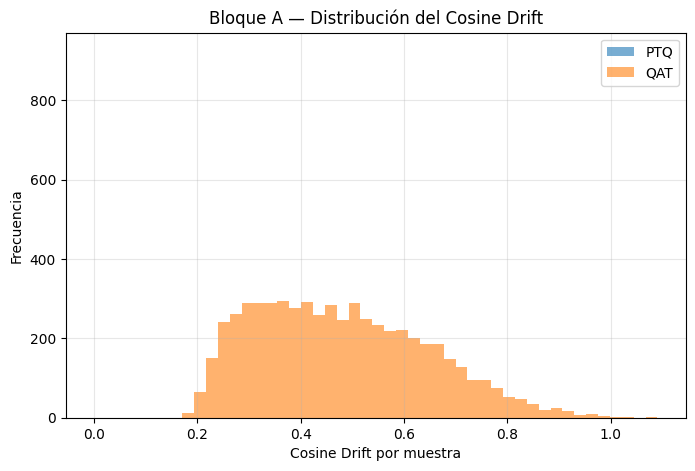

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(drift_ptq, bins=40, alpha=0.6, label="PTQ")
plt.hist(drift_qat, bins=40, alpha=0.6, label="QAT")
plt.xlabel("Cosine Drift por muestra")
plt.ylabel("Frecuencia")
plt.title("Bloque A — Distribución del Cosine Drift")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

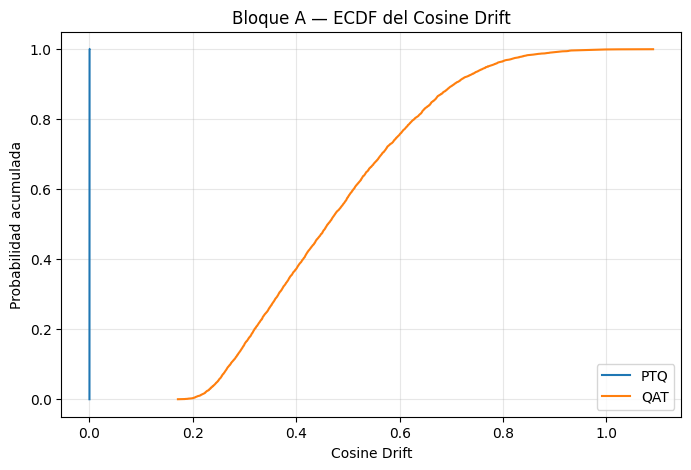

In [10]:
x_ptq, y_ptq = ecdf_values(drift_ptq)
x_qat, y_qat = ecdf_values(drift_qat)

plt.figure(figsize=(8, 5))
plt.plot(x_ptq, y_ptq, label="PTQ")
plt.plot(x_qat, y_qat, label="QAT")
plt.xlabel("Cosine Drift")
plt.ylabel("Probabilidad acumulada")
plt.title("Bloque A — ECDF del Cosine Drift")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

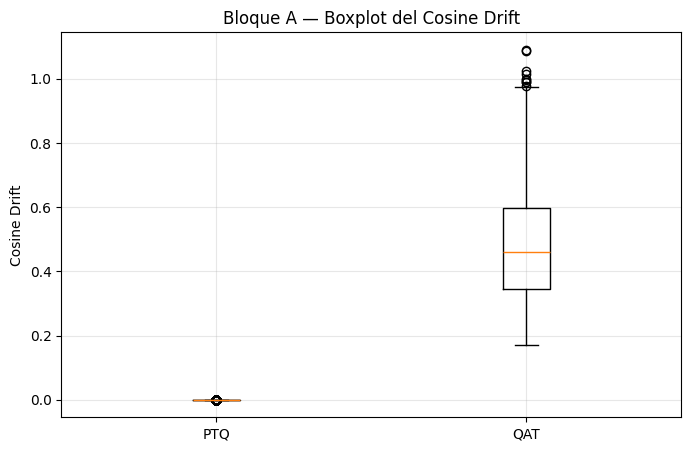

In [11]:
plt.figure(figsize=(8, 5))
plt.boxplot([drift_ptq, drift_qat], tick_labels=["PTQ", "QAT"])
plt.ylabel("Cosine Drift")
plt.title("Bloque A — Boxplot del Cosine Drift")
plt.grid(alpha=0.3)
plt.show()

In [12]:
thresholds = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
rows = []
for t in thresholds:
    rows.append({
        "threshold": t,
        "PTQ_prop_below": (drift_ptq <= t).mean(),
        "QAT_prop_below": (drift_qat <= t).mean(),
    })
pd.DataFrame(rows)

,threshold,PTQ_prop_below,QAT_prop_below
0,0.0001,0.847428,0.0
1,0.0005,1.000000,0.0
2,0.0010,1.000000,0.0
3,0.0050,1.000000,0.0
4,0.0100,1.000000,0.0


In [13]:
top_ptq = np.argsort(drift_ptq)[-TOP_OUTLIERS:][::-1].copy()
top_qat = np.argsort(drift_qat)[-TOP_OUTLIERS:][::-1].copy()

outliers_ptq = pd.DataFrame({
    "idx": top_ptq,
    "drift": drift_ptq[top_ptq],
    "cosine_similarity": cos_ptq[top_ptq],
    "angle_deg": ang_ptq[top_ptq],
    "label": labels[top_ptq].cpu().numpy(),
})
outliers_qat = pd.DataFrame({
    "idx": top_qat,
    "drift": drift_qat[top_qat],
    "cosine_similarity": cos_qat[top_qat],
    "angle_deg": ang_qat[top_qat],
    "label": labels[top_qat].cpu().numpy(),
})

print_heading("PTQ — muestras con mayor drift")
display(outliers_ptq)

print_heading("QAT — muestras con mayor drift")
display(outliers_qat)


PTQ — muestras con mayor drift


,idx,drift,cosine_similarity,angle_deg,label
0,620,0.000351,0.999649,1.518009,23
1,1276,0.000239,0.999761,1.252421,46
2,2990,0.000225,0.999775,1.215631,104
3,612,0.000223,0.999777,1.209175,23
4,3911,0.000220,0.999780,1.201708,136
5,551,0.000213,0.999787,1.181840,21
6,5361,0.000212,0.999788,1.179354,185
7,849,0.000208,0.999792,1.168519,31
8,3029,0.000205,0.999795,1.160958,106
9,5378,0.000204,0.999796,1.158596,185



QAT — muestras con mayor drift


,idx,drift,cosine_similarity,angle_deg,label
0,3071,1.090258,-0.090258,95.178452,107
1,2987,1.084960,-0.084960,94.873718,104
2,2267,1.023081,-0.023081,91.322571,79
3,2674,1.013666,-0.013666,90.783028,93
4,5364,0.998430,0.001570,89.910019,185
5,5013,0.995322,0.004678,89.731987,173
6,2970,0.988985,0.011015,89.368904,103
7,2980,0.988753,0.011247,89.355583,104
8,1870,0.978342,0.021658,88.758972,66
9,3927,0.974056,0.025944,88.513382,136


## Bloque A — análisis por clase

Esto te ayuda a ver si el drift se concentra en unas pocas clases o si el fenómeno es homogéneo.

In [14]:
df_a = pd.DataFrame({
    "label": labels.cpu().numpy(),
    "drift_ptq": drift_ptq,
    "drift_qat": drift_qat,
    "angle_ptq": ang_ptq,
    "angle_qat": ang_qat,
})

per_class_a = df_a.groupby("label").agg(
    drift_ptq_mean=("drift_ptq", "mean"),
    drift_qat_mean=("drift_qat", "mean"),
    angle_ptq_mean=("angle_ptq", "mean"),
    angle_qat_mean=("angle_qat", "mean"),
    n=("label", "size"),
).reset_index()

per_class_a["delta_drift_qat_minus_ptq"] = per_class_a["drift_qat_mean"] - per_class_a["drift_ptq_mean"]
per_class_a.sort_values("delta_drift_qat_minus_ptq").head(10)

,label,drift_ptq_mean,drift_qat_mean,angle_ptq_mean,angle_qat_mean,n,delta_drift_qat_minus_ptq
175,175,0.000094,0.325509,0.779833,46.913044,30,0.325415
82,82,0.000080,0.332229,0.716210,47.359428,30,0.332149
53,53,0.000073,0.333433,0.686915,47.628948,30,0.333361
188,188,0.000095,0.348786,0.782979,48.705692,30,0.348691
138,138,0.000087,0.354234,0.748699,49.020363,30,0.354148
147,147,0.000061,0.359412,0.627437,49.488171,30,0.359351
11,11,0.000063,0.360925,0.638160,49.772568,26,0.360862
74,74,0.000061,0.361425,0.624868,49.645626,27,0.361364
73,73,0.000072,0.362573,0.682843,49.901081,30,0.362501
72,72,0.000083,0.363304,0.731213,49.828701,30,0.363222


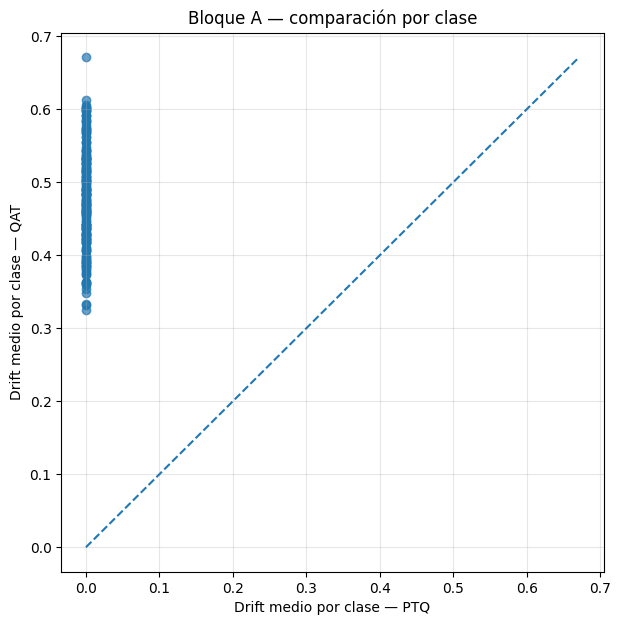

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(per_class_a["drift_ptq_mean"], per_class_a["drift_qat_mean"], alpha=0.7)
mn = min(per_class_a["drift_ptq_mean"].min(), per_class_a["drift_qat_mean"].min())
mx = max(per_class_a["drift_ptq_mean"].max(), per_class_a["drift_qat_mean"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Drift medio por clase — PTQ")
plt.ylabel("Drift medio por clase — QAT")
plt.title("Bloque A — comparación por clase")
plt.grid(alpha=0.3)
plt.show()

# Bloque B — estructura global

Aquí comparamos:

- **CKA**
- **Alignment**
- **Uniformity**

Y además miramos:

- alignment por clase,
- distribución global de similitudes coseno,
- y cómo cambia la ocupación del espacio entre FP32, PTQ y QAT.

In [16]:
b_ptq = block_b.run(emb_fp32, emb_ptq, labels)
b_qat = block_b.run(emb_fp32, emb_qat, labels)

comparison_b = pd.DataFrame([
    {"metric": "cka", "PTQ": b_ptq["cka"], "QAT": b_qat["cka"]},
    {"metric": "alignment_fp32", "PTQ": b_ptq["alignment_fp32"], "QAT": b_qat["alignment_fp32"]},
    {"metric": "alignment_quant", "PTQ": b_ptq["alignment_quant"], "QAT": b_qat["alignment_quant"]},
    {"metric": "delta_alignment", "PTQ": b_ptq["delta_alignment"], "QAT": b_qat["delta_alignment"]},
    {"metric": "uniformity_fp32", "PTQ": b_ptq["uniformity_fp32"], "QAT": b_qat["uniformity_fp32"]},
    {"metric": "uniformity_quant", "PTQ": b_ptq["uniformity_quant"], "QAT": b_qat["uniformity_quant"]},
    {"metric": "delta_uniformity", "PTQ": b_ptq["delta_uniformity"], "QAT": b_qat["delta_uniformity"]},
])
comparison_b

,metric,PTQ,QAT
0,cka,0.999908,0.403581
1,alignment_fp32,1.116333,1.116333
2,alignment_quant,1.116407,1.211138
3,delta_alignment,0.000075,0.094806
4,uniformity_fp32,-3.861777,-3.861777
5,uniformity_quant,-3.861744,-3.802422
6,delta_uniformity,0.000033,0.059355


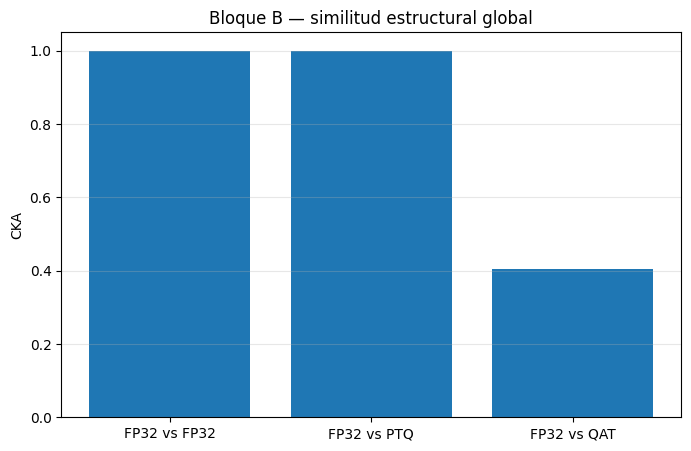

In [17]:
plt.figure(figsize=(8, 5))
x = np.arange(3)
cka_values = [1.0, b_ptq["cka"], b_qat["cka"]]
plt.bar(x, cka_values)
plt.xticks(x, ["FP32 vs FP32", "FP32 vs PTQ", "FP32 vs QAT"])
plt.ylabel("CKA")
plt.title("Bloque B — similitud estructural global")
plt.grid(alpha=0.3, axis="y")
plt.show()

In [18]:
def alignment_per_class(emb, labels, alpha=2.0):
    emb = torch.nn.functional.normalize(emb.float(), dim=1)
    rows = []
    for c in labels.unique():
        e = emb[labels == c]
        n = e.shape[0]
        if CLASS_SAMPLE_LIMIT is not None and n > CLASS_SAMPLE_LIMIT:
            idx = torch.randperm(n)[:CLASS_SAMPLE_LIMIT]
            e = e[idx]
            n = e.shape[0]
        if n < 2:
            continue
        diff = e.unsqueeze(0) - e.unsqueeze(1)
        dist = diff.norm(dim=2).pow(alpha)
        upper = dist.triu(diagonal=1)
        val = upper.sum().item() / (n * (n - 1) / 2)
        rows.append({"label": int(c.item()), "alignment": val, "n": n})
    return pd.DataFrame(rows)

align_class_fp32 = alignment_per_class(emb_fp32, labels)
align_class_ptq  = alignment_per_class(emb_ptq, labels)
align_class_qat  = alignment_per_class(emb_qat, labels)

align_compare = align_class_fp32.merge(align_class_ptq, on="label", suffixes=("_fp32", "_ptq"))
align_compare = align_compare.merge(align_class_qat[["label", "alignment"]], on="label")
align_compare = align_compare.rename(columns={"alignment": "alignment_qat"})
align_compare.head()

,label,alignment_fp32,n_fp32,alignment_ptq,n_ptq,alignment_qat
0,0,1.206235,30,1.206090,30,1.264106
1,1,1.290057,30,1.289359,30,1.369827
2,2,1.043170,28,1.042827,28,1.556152
3,3,1.260982,30,1.261112,30,0.991125
4,4,1.091075,14,1.090918,14,1.311987


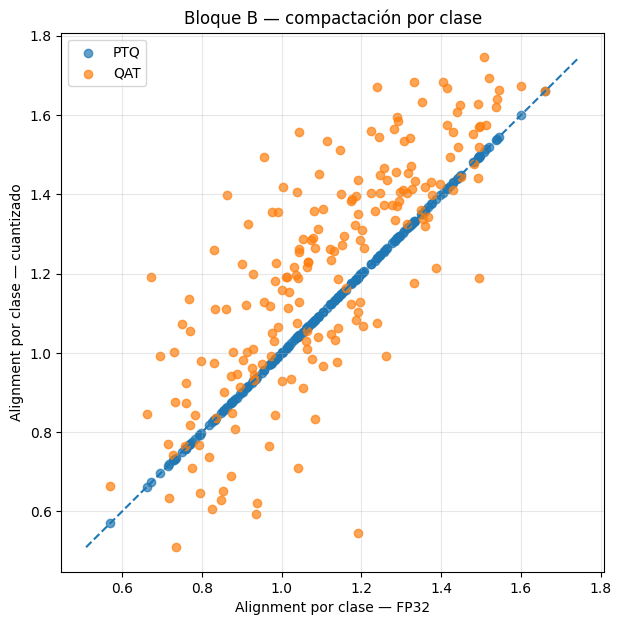

In [19]:
plt.figure(figsize=(7, 7))
plt.scatter(align_compare["alignment_fp32"], align_compare["alignment_ptq"], alpha=0.7, label="PTQ")
plt.scatter(align_compare["alignment_fp32"], align_compare["alignment_qat"], alpha=0.7, label="QAT")
mn = min(align_compare["alignment_fp32"].min(), align_compare["alignment_ptq"].min(), align_compare["alignment_qat"].min())
mx = max(align_compare["alignment_fp32"].max(), align_compare["alignment_ptq"].max(), align_compare["alignment_qat"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Alignment por clase — FP32")
plt.ylabel("Alignment por clase — cuantizado")
plt.title("Bloque B — compactación por clase")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

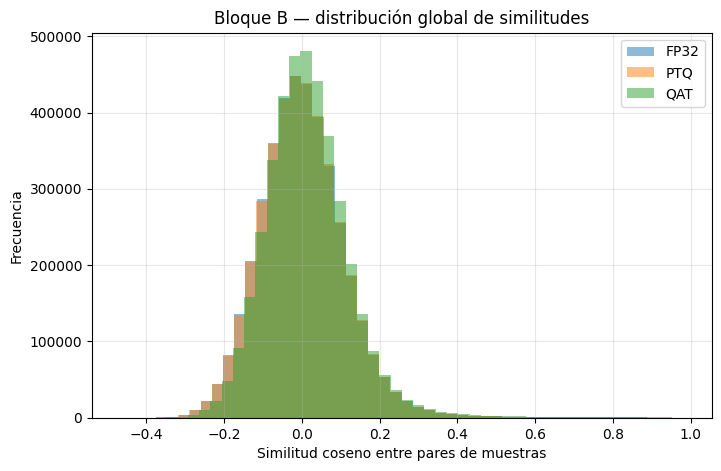

In [20]:
pair_cos_fp32 = pairwise_cosine_sample(emb_fp32, max_rows=PAIRWISE_SAMPLE_SIZE)
pair_cos_ptq  = pairwise_cosine_sample(emb_ptq, max_rows=PAIRWISE_SAMPLE_SIZE)
pair_cos_qat  = pairwise_cosine_sample(emb_qat, max_rows=PAIRWISE_SAMPLE_SIZE)

plt.figure(figsize=(8, 5))
plt.hist(pair_cos_fp32, bins=50, alpha=0.5, label="FP32")
plt.hist(pair_cos_ptq, bins=50, alpha=0.5, label="PTQ")
plt.hist(pair_cos_qat, bins=50, alpha=0.5, label="QAT")
plt.xlabel("Similitud coseno entre pares de muestras")
plt.ylabel("Frecuencia")
plt.title("Bloque B — distribución global de similitudes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bloque C — preservación de vecindarios

Aquí comparamos **PTQ vs QAT** para varios valores de `k` y además miramos:

- curvas Overlap@k,
- distribución por muestra para un `k` fijo,
- y comparación por clase del solapamiento local.

In [21]:
c_ptq = block_c.run(emb_fp32, emb_ptq, ks=K_VALUES)
c_qat = block_c.run(emb_fp32, emb_qat, ks=K_VALUES)

comparison_c = pd.DataFrame({
    "k": K_VALUES,
    "PTQ": [c_ptq[f"overlap_at_{k}"] for k in K_VALUES],
    "QAT": [c_qat[f"overlap_at_{k}"] for k in K_VALUES],
})
comparison_c

,k,PTQ,QAT
0,1,0.982568,0.097687
1,5,0.989506,0.242768
2,10,0.992320,0.345202
3,20,0.994304,0.434208


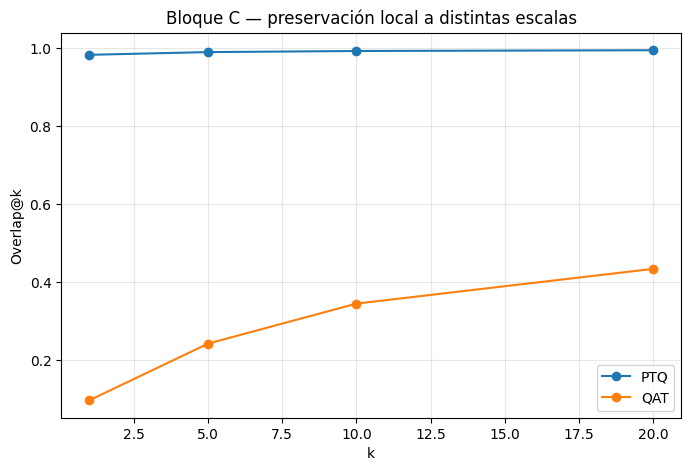

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(comparison_c["k"], comparison_c["PTQ"], marker="o", label="PTQ")
plt.plot(comparison_c["k"], comparison_c["QAT"], marker="o", label="QAT")
plt.xlabel("k")
plt.ylabel("Overlap@k")
plt.title("Bloque C — preservación local a distintas escalas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
K_ANALYSIS = 10

overlap_ptq_per_sample = to_numpy(block_c.overlap_at_k_per_sample(emb_fp32, emb_ptq, k=K_ANALYSIS))
overlap_qat_per_sample = to_numpy(block_c.overlap_at_k_per_sample(emb_fp32, emb_qat, k=K_ANALYSIS))

summary_c = pd.concat([
    summarize_array(overlap_ptq_per_sample, f"PTQ_overlap@{K_ANALYSIS}"),
    summarize_array(overlap_qat_per_sample, f"QAT_overlap@{K_ANALYSIS}"),
], axis=1).T

summary_c

,name,count,mean,std,min,p25,median,p75,p90,p95,p99,max
0,PTQ_overlap@10,5794,0.99232,0.026628,0.9,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,QAT_overlap@10,5794,0.345202,0.269568,0.0,0.1,0.3,0.6,0.7,0.8,0.9,1.0


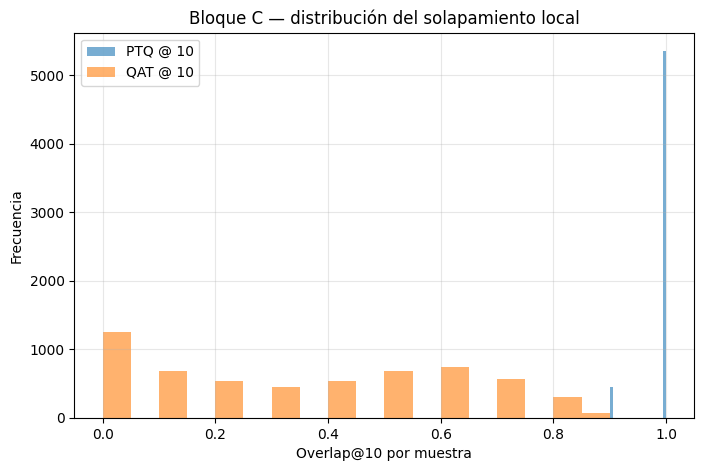

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(overlap_ptq_per_sample, bins=20, alpha=0.6, label=f"PTQ @ {K_ANALYSIS}")
plt.hist(overlap_qat_per_sample, bins=20, alpha=0.6, label=f"QAT @ {K_ANALYSIS}")
plt.xlabel(f"Overlap@{K_ANALYSIS} por muestra")
plt.ylabel("Frecuencia")
plt.title("Bloque C — distribución del solapamiento local")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

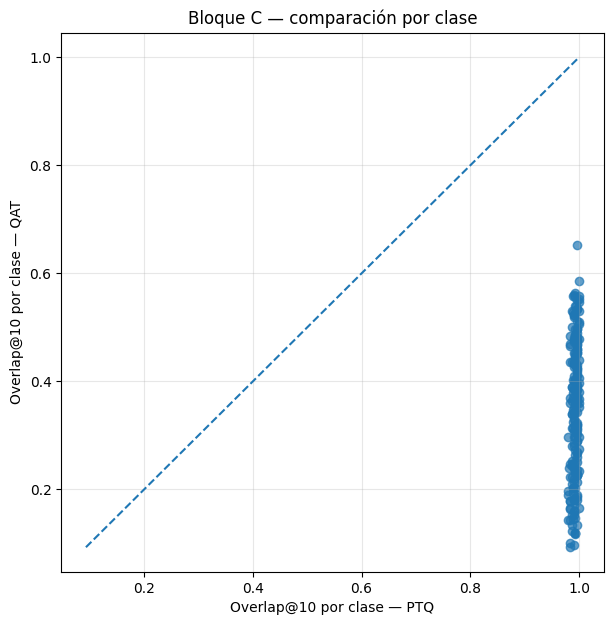

In [25]:
df_c = pd.DataFrame({
    "label": labels.cpu().numpy(),
    f"overlap_ptq_{K_ANALYSIS}": overlap_ptq_per_sample,
    f"overlap_qat_{K_ANALYSIS}": overlap_qat_per_sample,
})

per_class_c = df_c.groupby("label").agg(
    overlap_ptq_mean=(f"overlap_ptq_{K_ANALYSIS}", "mean"),
    overlap_qat_mean=(f"overlap_qat_{K_ANALYSIS}", "mean"),
    n=("label", "size"),
).reset_index()

plt.figure(figsize=(7, 7))
plt.scatter(per_class_c["overlap_ptq_mean"], per_class_c["overlap_qat_mean"], alpha=0.7)
mn = min(per_class_c["overlap_ptq_mean"].min(), per_class_c["overlap_qat_mean"].min())
mx = max(per_class_c["overlap_ptq_mean"].max(), per_class_c["overlap_qat_mean"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel(f"Overlap@{K_ANALYSIS} por clase — PTQ")
plt.ylabel(f"Overlap@{K_ANALYSIS} por clase — QAT")
plt.title("Bloque C — comparación por clase")
plt.grid(alpha=0.3)
plt.show()

# Bloque D — dimensionalidad efectiva y espectro singular

Aquí no nos quedamos solo con `EDim`. También miramos:

- espectro singular,
- espectro normalizado,
- masa espectral acumulada,
- y cómo se reparte la dimensionalidad efectiva entre FP32, PTQ y QAT.

In [26]:
d_ptq = block_d.run(emb_fp32, emb_ptq)
d_qat = block_d.run(emb_fp32, emb_qat)

comparison_d = pd.DataFrame([
    {"metric": "edim_fp32", "PTQ": d_ptq["edim_fp32"], "QAT": d_qat["edim_fp32"]},
    {"metric": "edim_quant", "PTQ": d_ptq["edim_quant"], "QAT": d_qat["edim_quant"]},
    {"metric": "delta_edim", "PTQ": d_ptq["delta_edim"], "QAT": d_qat["delta_edim"]},
])
comparison_d

,metric,PTQ,QAT
0,edim_fp32,314.305756,314.305756
1,edim_quant,314.390717,341.424011
2,delta_edim,0.084961,27.118256


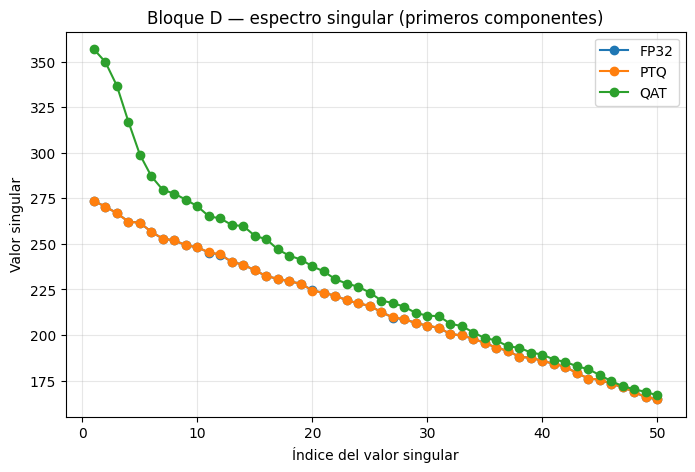

In [27]:
s_fp32, p_fp32, cum_fp32 = singular_spectrum(emb_fp32)
s_ptq,  p_ptq,  cum_ptq  = singular_spectrum(emb_ptq)
s_qat,  p_qat,  cum_qat  = singular_spectrum(emb_qat)

TOP_SINGULAR = 50

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, TOP_SINGULAR + 1), s_fp32[:TOP_SINGULAR], marker="o", label="FP32")
plt.plot(np.arange(1, TOP_SINGULAR + 1), s_ptq[:TOP_SINGULAR], marker="o", label="PTQ")
plt.plot(np.arange(1, TOP_SINGULAR + 1), s_qat[:TOP_SINGULAR], marker="o", label="QAT")
plt.xlabel("Índice del valor singular")
plt.ylabel("Valor singular")
plt.title("Bloque D — espectro singular (primeros componentes)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

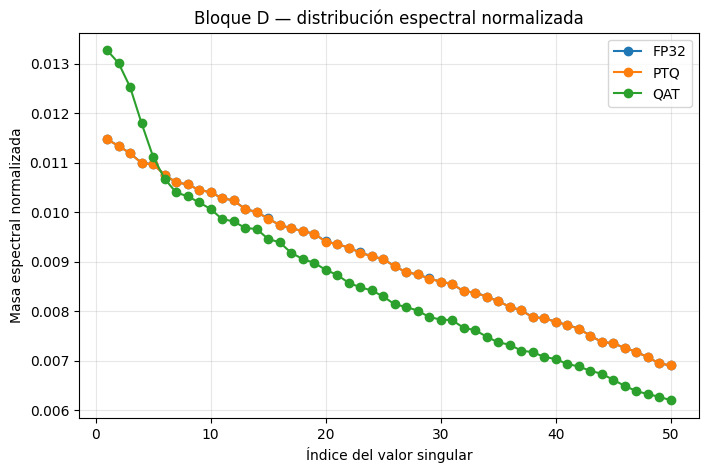

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, TOP_SINGULAR + 1), p_fp32[:TOP_SINGULAR], marker="o", label="FP32")
plt.plot(np.arange(1, TOP_SINGULAR + 1), p_ptq[:TOP_SINGULAR], marker="o", label="PTQ")
plt.plot(np.arange(1, TOP_SINGULAR + 1), p_qat[:TOP_SINGULAR], marker="o", label="QAT")
plt.xlabel("Índice del valor singular")
plt.ylabel("Masa espectral normalizada")
plt.title("Bloque D — distribución espectral normalizada")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

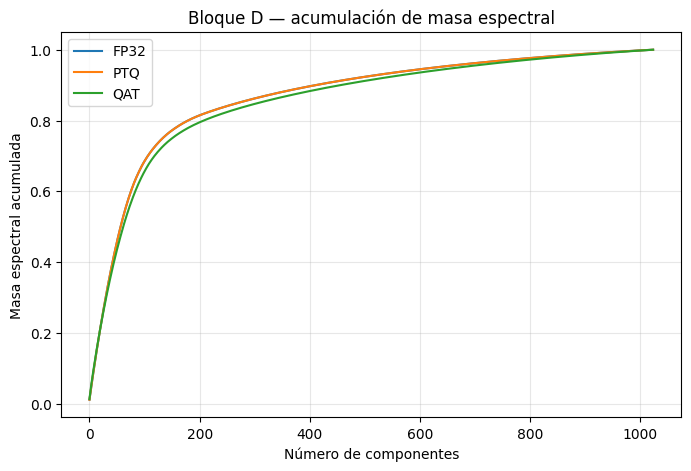

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(cum_fp32, label="FP32")
plt.plot(cum_ptq, label="PTQ")
plt.plot(cum_qat, label="QAT")
plt.xlabel("Número de componentes")
plt.ylabel("Masa espectral acumulada")
plt.title("Bloque D — acumulación de masa espectral")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [30]:
def dims_for_mass(cum, masses=(0.80, 0.90, 0.95, 0.99)):
    rows = []
    for m in masses:
        idx = int(np.searchsorted(cum, m) + 1)
        rows.append((m, idx))
    return rows

mass_table = pd.DataFrame({
    "mass": [0.80, 0.90, 0.95, 0.99],
    "FP32_dims": [d for _, d in dims_for_mass(cum_fp32)],
    "PTQ_dims":  [d for _, d in dims_for_mass(cum_ptq)],
    "QAT_dims":  [d for _, d in dims_for_mass(cum_qat)],
})
mass_table

,mass,FP32_dims,PTQ_dims,QAT_dims
0,0.80,180,180,209
1,0.90,412,412,457
2,0.95,629,629,672
3,0.99,916,916,932


# Lectura integrada de resultados

Esta celda reúne los principales resultados en una sola tabla para facilitar la comparación PTQ vs QAT.

In [31]:
integrated = pd.DataFrame([
    {
        "block": "A",
        "metric": "cosine_drift_mean",
        "PTQ": float(a_ptq["cosine_drift"]),
        "QAT": float(a_qat["cosine_drift"]),
        "better_direction": "menor"
    },
    {
        "block": "A",
        "metric": "angle_deg_mean",
        "PTQ": float(ang_ptq.mean()),
        "QAT": float(ang_qat.mean()),
        "better_direction": "menor"
    },
    {
        "block": "B",
        "metric": "cka",
        "PTQ": float(b_ptq["cka"]),
        "QAT": float(b_qat["cka"]),
        "better_direction": "mayor"
    },
    {
        "block": "B",
        "metric": "delta_alignment",
        "PTQ": float(b_ptq["delta_alignment"]),
        "QAT": float(b_qat["delta_alignment"]),
        "better_direction": "menor"
    },
    {
        "block": "B",
        "metric": "delta_uniformity",
        "PTQ": float(b_ptq["delta_uniformity"]),
        "QAT": float(b_qat["delta_uniformity"]),
        "better_direction": "menor"
    },
    {
        "block": "C",
        "metric": f"overlap_at_{K_ANALYSIS}",
        "PTQ": float(block_c.overlap_at_k(emb_fp32, emb_ptq, k=K_ANALYSIS)),
        "QAT": float(block_c.overlap_at_k(emb_fp32, emb_qat, k=K_ANALYSIS)),
        "better_direction": "mayor"
    },
    {
        "block": "D",
        "metric": "delta_edim",
        "PTQ": float(d_ptq["delta_edim"]),
        "QAT": float(d_qat["delta_edim"]),
        "better_direction": "más cercano a 0 / menos negativo"
    },
])

integrated

,block,metric,PTQ,QAT,better_direction
0,A,cosine_drift_mean,0.000078,0.478098,menor
1,A,angle_deg_mean,0.707053,57.886848,menor
2,B,cka,0.999908,0.403581,mayor
3,B,delta_alignment,0.000075,0.094806,menor
4,B,delta_uniformity,0.000033,0.059355,menor
5,C,overlap_at_10,0.992320,0.345202,mayor
6,D,delta_edim,0.084961,27.118256,más cercano a 0 / menos negativo


## Sugerencias para interpretar

- **Bloque A**: si QAT tiene menor drift medio, menor ángulo y mejores percentiles altos, preserva mejor la fidelidad angular individual.
- **Bloque B**: si QAT tiene mayor CKA, menor delta de alignment y menor delta de uniformity, preserva mejor la estructura global.
- **Bloque C**: si QAT tiene mayor Overlap@k, preserva mejor la estructura local.
- **Bloque D**: si QAT tiene una caída menor de EDim y un espectro menos concentrado, preserva mejor la riqueza espectral.

La comparación fuerte no es solo por un escalar, sino por el **perfil completo**:
- medias,
- percentiles,
- colas,
- análisis por clase,
- vecindarios,
- y espectro singular.